# Example Notebook

This notebook provides an illustrative example of the analyses conducted to investigate underrepresented groups within the EU-SILC dataset.

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import sem, describe, chi2_contingency, chisquare
from scipy.spatial.distance import cdist
from collections import defaultdict
from sklearn.cluster import KMeans, SpectralClustering, AgglomerativeClustering
from sklearn.metrics import matthews_corrcoef, accuracy_score, silhouette_score
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.model_selection import LeaveOneOut, KFold, LeavePOut
from sklearn.decomposition import PCA, KernelPCA
from astropy.stats import jackknife_stats
import seaborn as sns

###tensorflow
import tensorflow as tf
from keras.layers import Layer, InputSpec
from keras import initializers, regularizers, constraints
import keras.backend as K

#
import Outlier_Detection_EUSILC as OD


### set the numpy.random seed
seed = 6
tf.random.set_seed(seed)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["PYTHONHASHSEED"] = str(seed)
random.seed(seed)
np.random.seed(seed)

# Set the style
sns.set_style("whitegrid")  # or "ticks" for cleaner look

# Set general font scale
sns.set_context("paper", font_scale=1.5)  # Options: "notebook", "talk", "poster"

# Optional: Customize Matplotlib parameters
plt.rcParams.update({
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.dpi': 300,           # For high-quality raster formats
    'savefig.dpi': 300,
    'figure.figsize': (6, 4),    # Width x Height in inches
    'font.family': 'serif',      # Or 'sans-serif' if preferred
})

2025-12-14 18:37:20.824578: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# get the utils from the Outlier Detection Module
utils = OD.Utils()

# Read the data

- The file `Ready_to_use_Data_Lig2019.csv` refers to the tabular dataset already prepared for the research purposes of this study, including preprocessing, variable selection, and harmonization steps.

- This file is not included in the repository because the data are owned by a third party and are not publicly available. Access may be granted upon reasonable request and subject to approval by the data owner

In [3]:
#read the 2019 EU-SILC data for the Ligurian Sector
path_data = "Ready_to_use_Data_Lig2019.csv"
df = pd.read_csv(path_data, sep= ',')

# Data Preparation -- Pre-processing (further steps)

1. Overwrite the age variables with the age groups
2. Create a Python dictionary which maps columns (variable names) to a variable's description
3. Gets the variable toi get investigated
4. get the weights (sapling weights), as they are included in the df df datset aldeady

In [4]:
#overwrite the age variable with the age groups
df["ETAINT"] = utils.bin_ages(df["ETAINT"])

#get a list with the variables' name
features_ = ["ETAINT",'CITTADX', 'NCITT', 'SECITT', 'ITA', "TIPSCU",
       'VIFAM', 'LAVPRI', 'FONTERED', 'TOT_TUTTI', 'RAGA017', 'DON1555',
       'STACIV', 'TF', 'SEV_MAT_DEPRIV', 'RISKPOV', 'LOW_WORK_INT',
       'POV_SOC_EXCL', 'QUINTI_EU']


#Create a 
features_dict = utils.features_dict()

#
categorisation = utils.categorization_dict()

# get the variables to investigate.
X = df[features_].values

#get the sampling weights -- the weights of the sampling design
weights = df["psi_weights"].values

# get the normalised version opf the weights
weights_norm = weights/weights.sum()

In [5]:
# print a table as a latex table which provides the Variables name and their descrtiption
varibale_descritpion = pd.DataFrame(list(features_dict.items()), columns=["Variable", "Description"])
varibale_descritpion.to_latex()

"\\begin{tabular}{lll}\n\\toprule\n & Variable & Description \\\\\n\\midrule\n0 & ETAINT & Respondent's age \\\\\n1 & CITTADX & Italian Cizitenship \\\\\n2 & NCITT & Italian citizen from birth \\\\\n3 & SECITT & Secondary Cizitenship (if applicable) \\\\\n4 & ITA & Nerver moved out of Italy \\\\\n5 & VIFAM & Lived within the household for the whole 2019 \\\\\n6 & LAVPRI & Employment status or occupation type \\\\\n7 & FONTERED & Source of income or funding \\\\\n8 & TOT_TUTTI & Number of individuals in the household \\\\\n9 & RAGA017 & Number of minor Children within the household \\\\\n10 & DON1555 & Number of women aged 15-55 \\\\\n11 & STACIV & Civil status \\\\\n12 & TF & Type of family \\\\\n13 & TIPSCU & Type of school attended (if applicable) \\\\\n14 & SEV_MAT_DEPRIV & Severity of material deprivation \\\\\n15 & RISKPOV & Risk of poverty indicator \\\\\n16 & LOW_WORK_INT & Indicator of low work intensity \\\\\n17 & POV_SOC_EXCL & Social exclusion due to poverty \\\\\n18 & QUINT

# Plot -- Comparision between the tax declaration dataset and the EU-SILC data 

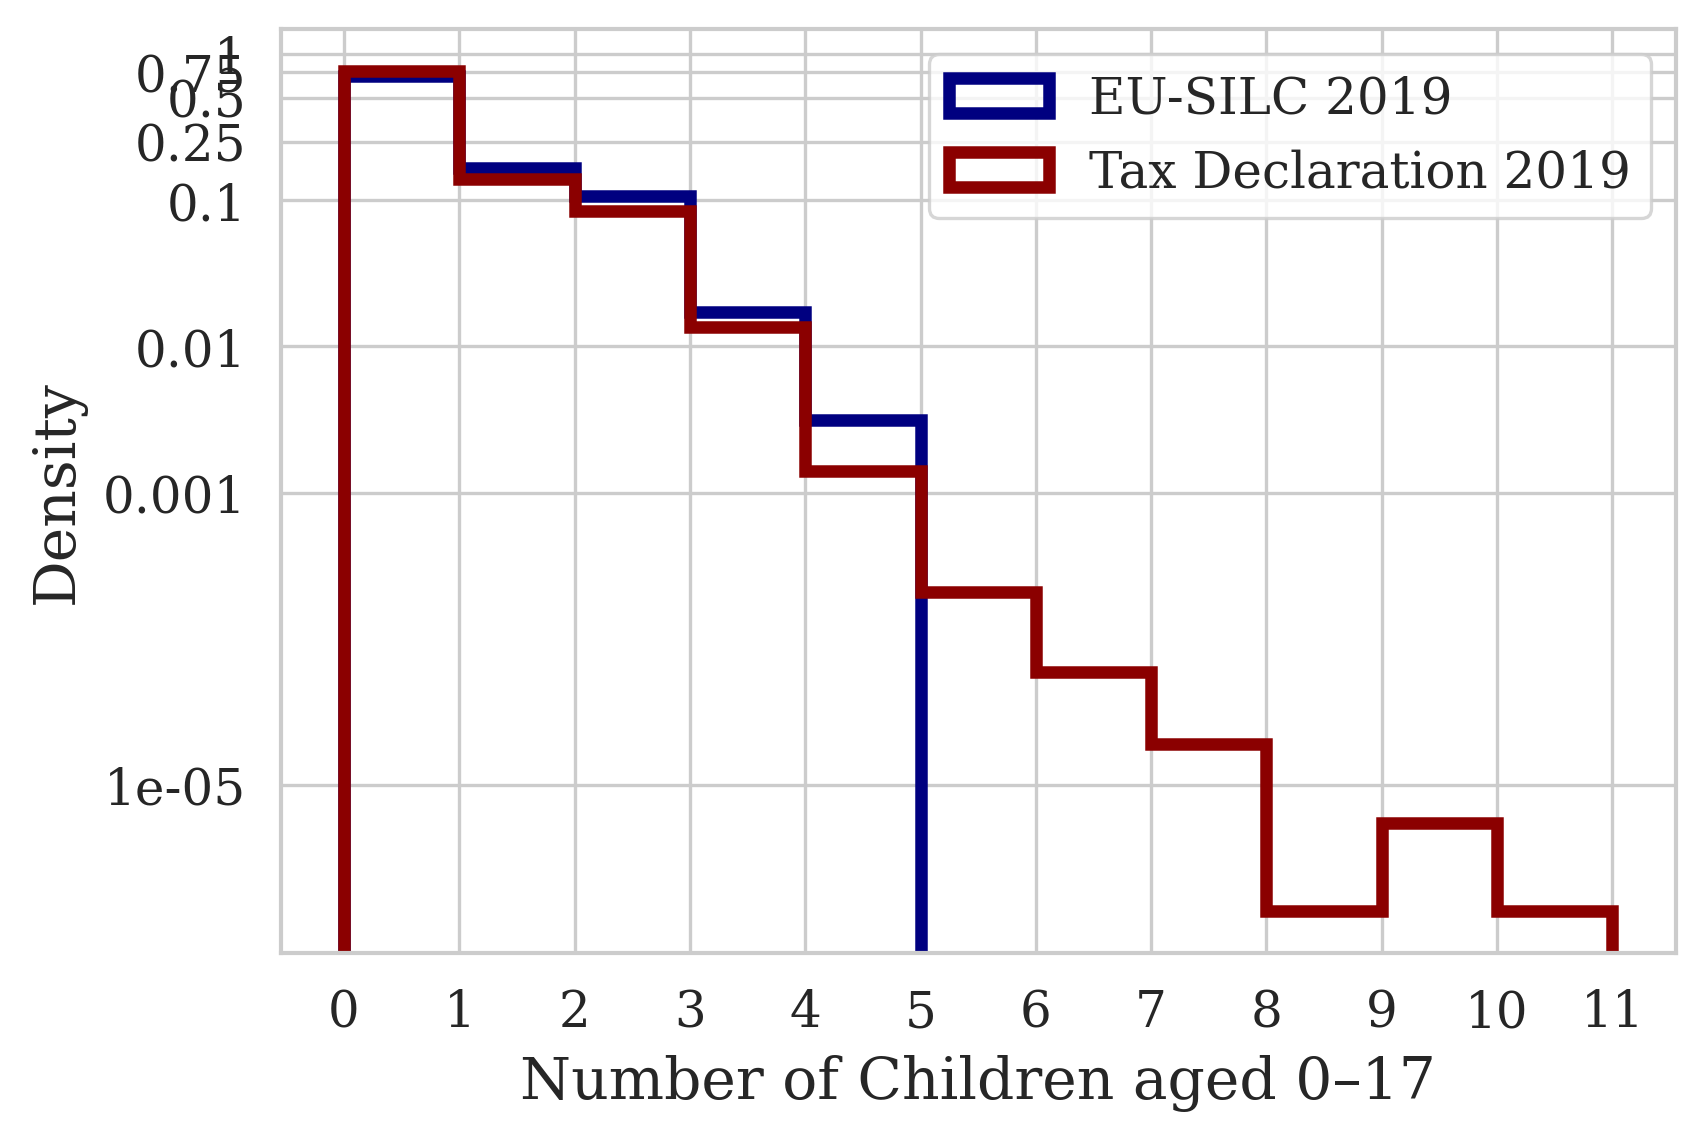

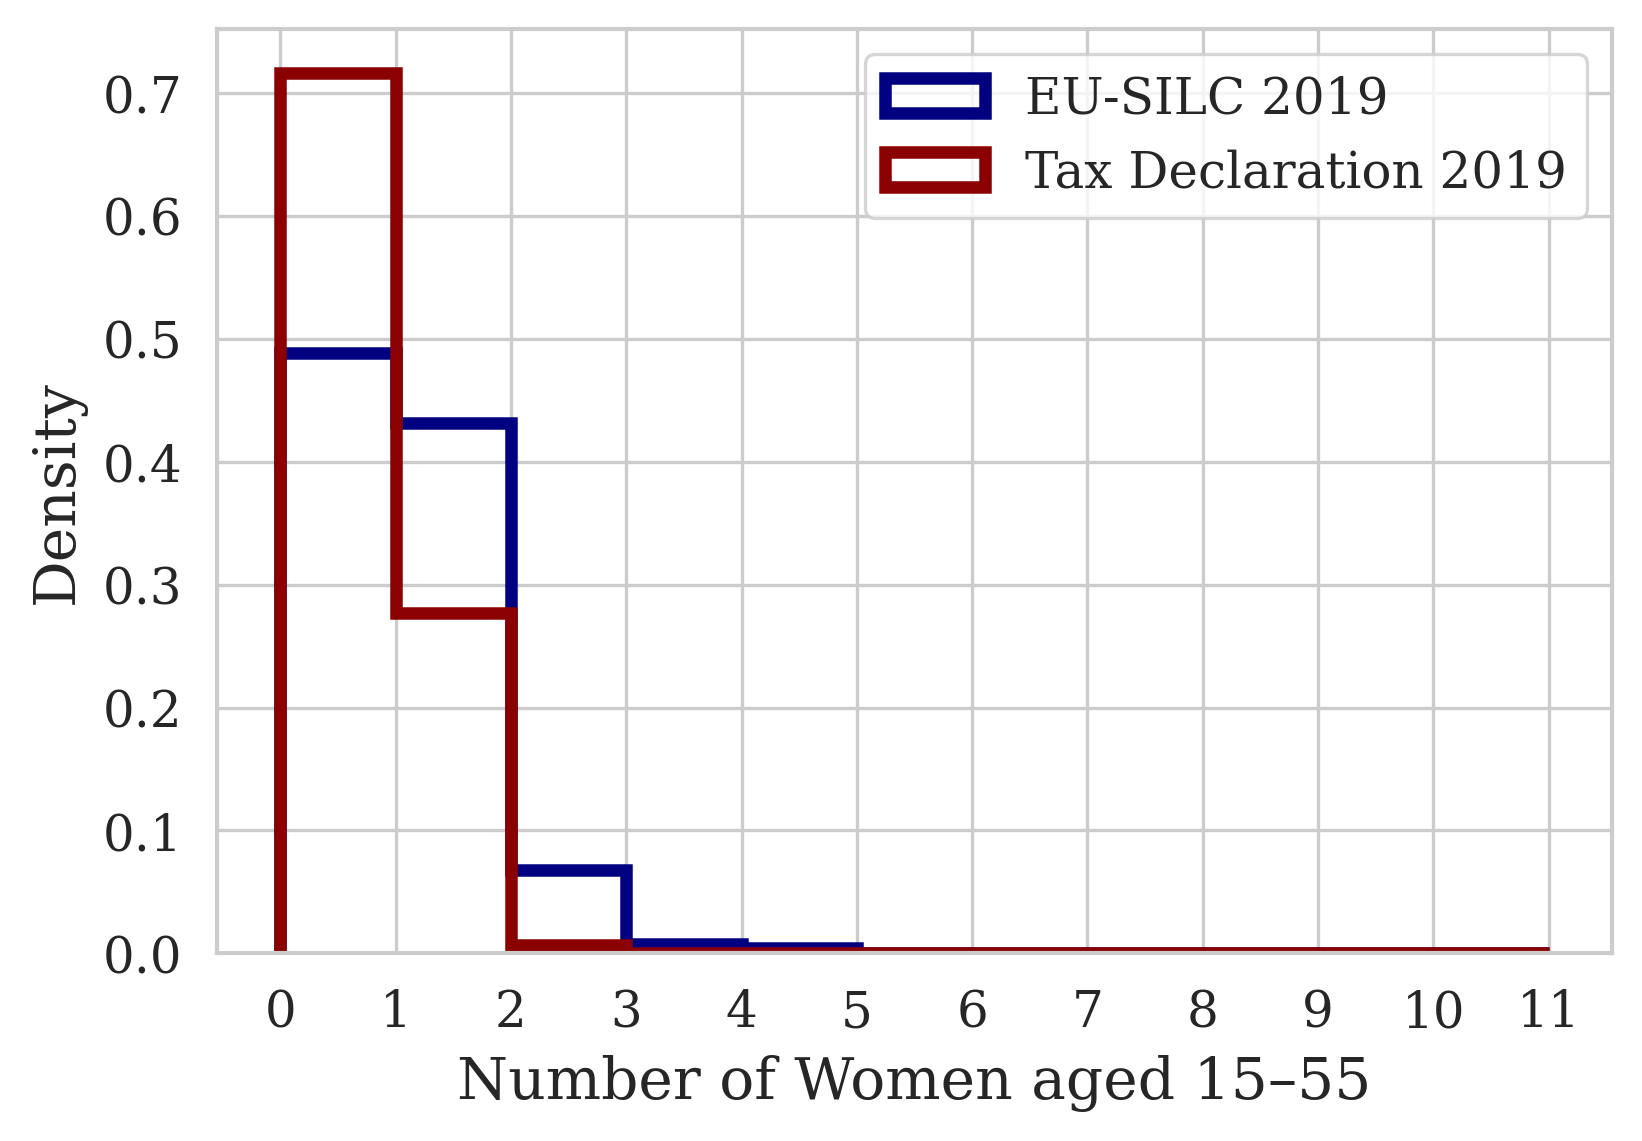

In [6]:
# --- Load the Liguria Tax Declaration dataset (Year of Reference: 2019) ---
# Specify the path to the dataset
df_tax_path = "/Users/pinguino/Documents/Regione_Liguria_Famiglie/Scripts/LIG_ANAG_MFS_DATA_MAY2025.csv"

# Read the CSV file, using ';' as the field separator (common in Italian datasets)
df_tax = pd.read_csv(df_tax_path, sep=';')

# -----------------------------------------------------------------------------
# PLOT 1: Comparison of the Number of Children (aged 0–17)
# between EU-SILC 2019 and Tax Declaration 2019
# -----------------------------------------------------------------------------

# Plot histogram for EU-SILC 2019 dataset
plt.hist(
    df["RAGA017"].values,                   # Variable: number of children aged 0–17
    bins=np.arange(0, 12, 1),               # Define bin edges: 0 to 11 children
    color="navy",                           # Blue outline for EU-SILC data
    weights=weights_norm,                   # Apply normalized survey weights
    histtype='step',                        # Use step-line style for clarity
    linewidth=3,                            # Thicker line for better visibility
    label="EU-SILC 2019"                    # Legend label
)

# Label axes
plt.xlabel("Number of Children aged 0–17")
plt.ylabel("Density")

# Use logarithmic scale to enhance visibility of lower frequencies
plt.yscale('log')

# Define tick positions and labels manually for readability
plt.yticks(
    [1e-5, 1e-3, 1e-2, 1e-1, 25e-2, 5e-1, 75e-2, 1],
    [1e-5, 1e-3, 1e-2, 1e-1, 25e-2, 5e-1, 75e-2, 1]
)

# Add grid for better interpretability of values
plt.grid(True)

# Overlay Tax Declaration 2019 histogram on the same figure
plt.hist(
    df_tax["Num_Children"].values,          # Variable: number of children aged 0–17
    bins=np.arange(0, 12, 1),               # Same binning for comparison
    color="darkred",                        # Red outline for Tax Declaration data
    density=True,                           # Normalize to show density
    histtype='step',                        # Use step-line style
    linewidth=3,                            # Thicker line
    label="Tax Declaration 2019"            # Legend label
)

# Re-label axes (redundant but ensures clarity)
plt.xlabel("Number of Children aged 0–17")
plt.ylabel("Density")

# Maintain log scale and custom tick labels for consistent visualization
plt.yscale('log')
plt.yticks(
    [1e-5, 1e-3, 1e-2, 1e-1, 25e-2, 5e-1, 75e-2, 1],
    [1e-5, 1e-3, 1e-2, 1e-1, 25e-2, 5e-1, 75e-2, 1]
)
plt.grid(True)

# Set x-axis ticks corresponding to integer numbers of children
plt.xticks(np.arange(0, 12, 1), np.arange(0, 12, 1))

# Display legend to distinguish datasets
plt.legend()

# Save the figure as a high-quality PDF file
plt.savefig("EUSILC_TAX_Declaration_2019_Children.pdf")

# Display the plot
plt.show()


# -----------------------------------------------------------------------------
# PLOT 2: Comparison of the Number of Women (aged 15–55)
# between EU-SILC 2019 and Tax Declaration 2019
# -----------------------------------------------------------------------------

# Plot histogram for EU-SILC 2019
plt.hist(
    df["DON1555"].values,                  # Variable: number of women aged 15–55
    bins=np.arange(0, 12, 1),              # Define bin edges
    color="navy",
    weights=weights_norm,                  # Apply normalized survey weights
    histtype='step',
    linewidth=3,
    label="EU-SILC 2019"
)

plt.xlabel("Number of Women aged 15–55")
plt.ylabel("Density")
# The log scale is commented out here — linear scale may be more interpretable for this variable
# plt.yscale('log')
plt.grid(True)

# Overlay Tax Declaration data
plt.hist(
    df_tax["Donne1555"].values,            # Variable: number of women aged 15–55
    bins=np.arange(0, 12, 1),
    color="darkred",
    density=True,                          # Normalize for comparability
    histtype='step',
    linewidth=3,
    label="Tax Declaration 2019"
)

plt.xlabel("Number of Women aged 15–55")
plt.ylabel("Density")
plt.grid(True)
plt.legend()

# Set x-axis ticks corresponding to integer numbers of women in household
plt.xticks(np.arange(0, 12, 1), np.arange(0, 12, 1))

# Save figure
plt.savefig("EUSILC_TAX_Declaration_2019_Women.pdf")

# Display plot
plt.show()


# Entropy Score

1. Get the EntropyScore class and initialise it with the EU-SILC data
2. make the evaluaton of the Entropy-based statistic to reveal the underrepresented groups.
3. Use the function get_entropy)_data_frame to get a summary dataframe with the entropy based statistci and the laabel to the typical (represented) or atypical (underrepresented) group.

In [7]:
entropy_score = OD.EntropyScore(X, weights, feature_names=features_)
entropy_score.get_entropy_dataframe()

,Variable_Name,entropy_score,cluster
0,VIFAM,0.951527,atypical
1,SECITT,0.874917,atypical
2,SEV_MAT_DEPRIV,0.804957,atypical
3,TIPSCU,0.737139,atypical
4,CITTADX,0.725303,atypical
5,NCITT,0.714841,atypical
6,ITA,0.657279,atypical
7,RISKPOV,0.498129,typical
8,RAGA017,0.459679,typical
9,DON1555,0.405058,typical


# Stability Validation for Entropy Score method

In [8]:
entropy_score.stability_validation()

{'validation_score': 0.9970760233918088,
 'confidence_interval': array([0.99134513, 1.00280691])}

# Internal Validation for Entropy Score method

In [9]:
entropy_score.internal_validation()

{'validation_score': 0.9941176470588236,
 'confidence_interval': array([0.98258845, 1.00564685])}

# Outlier Detection with KPCA and AE

In [ ]:
#import Outlier Detection class for both KPCA and AE
od_kpca = OD.OutlierDetection(data=X, weights=weights_norm,
                           feature_names=features_,
                           method="KPCA",
                           variance_explained=.999)

od_ae = OD.OutlierDetection(data=X, weights=weights_norm,
                         feature_names=features_,
                         method="AE",
                         variance_explained=.999)


2025-12-14 18:38:38.709029: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


: 

In [ ]:
#Variable Importanc--KPCA -- get the importance score
vi_kpca = od_kpca.get_importance_dataframe()

#Variable Importanc--AE -- get the importance score
vi_ae = od_ae.get_importance_dataframe()

#change the variable name by using the feature dict 
vi_kpca["Variable_Name"] = vi_kpca["Variable_Name"].map(features_dict)
vi_ae["Variable_Name"] = vi_ae["Variable_Name"].map(features_dict)

### Evaluate the validation score for stability (KPCA)

In [ ]:
od_kpca.validate_stability()

{'validation_score': 1.0, 'confidence_interval': array([1., 1.])}

### Evaluate the validation score for internal validation (KPCA)

In [ ]:
od_kpca.internal_validation()

Fold: 1
Fold: 2
Fold: 3
Fold: 4
Fold: 5
Fold: 6
Fold: 7
Fold: 8
Fold: 9
Fold: 10


{'mcc_mean': 0.9986875989327473, 'mcc_sem': 0.0013129430541491864}

### Evaluate the validation score for stability (AE)

In [ ]:
# AE -- validate stability
od_ae.validate_stability()

{'validation_score': 0.9999451008728836,
 'confidence_interval': array([0.99988616, 1.00000404])}

### Evaluate the validation score for stability (AE)

In [ ]:
# AE -- internal validation
od_ae.internal_validation()

Fold: 1
Fold: 2
Fold: 3
Fold: 4
Fold: 5
Fold: 6
Fold: 7
Fold: 8
Fold: 9
Fold: 10


{'mcc_mean': 0.9903003615945636, 'mcc_sem': 0.009829872268692317}

In [ ]:
## This block just prints out the results in latex format

latex_df_imp = vi_ae.to_latex(index=False, 
                caption='Average Importance score for both KPCA and AE', 
                label='tab: Average_Importance', 
                escape=False)
latex_df_imp = latex_df_imp.replace('\n', ' ')
print(latex_df_imp)


\begin{table} \caption{Average Importance score for both KPCA and AE} \label{tab: Average_Importance} \begin{tabular}{lr} \toprule Variable_Name & Average Importance (AE) \\ \midrule Employment status or occupation type & 0.205126 \\ Source of income or funding & 0.173818 \\ Respondent's age & 0.115394 \\ Number of individuals in the household & 0.110061 \\ Indicator of low work intensity & 0.079377 \\ Type of school attended (if applicable) & 0.075498 \\ Civil status & 0.056104 \\ Number of minor Children within the household & 0.049766 \\ Type of family & 0.042286 \\ Number of women aged 15-55 & 0.015567 \\ Lived within the household for the whole 2019 & 0.005160 \\ Quintile in the European Union economic ranking & 0.004658 \\ Italian Cizitenship & 0.001195 \\ Italian citizen from birth & 0.001091 \\ Secondary Cizitenship (if applicable) & 0.000710 \\ Risk of poverty indicator & 0.000208 \\ Severity of material deprivation & 0.000035 \\ Nerver moved out of Italy & 0.000017 \\ Social 

Analysis on the medoids for exploring the under-represented population

In [ ]:
med_kpca = od_kpca._make_subclustering(max_n_clusters=10)
med_kpca = utils.map_long_format_categories(med_kpca, categorisation)
med_kpca["Variable_Name"] = med_kpca["Variable_Name"].map(features_dict)


latex_df_imp = med_kpca.to_latex(index=False, 
                caption='Average Importance score for both KPCA and AE', 
                label='tab: Average_Importance', 
                escape=False)
latex_df_imp = latex_df_imp.replace('\n', ' ')
print(latex_df_imp)

Silhouette_Score: 0.24119832550852896


NameError: name 'map_long_format_categories' is not defined

In [ ]:
med_ae = od_ae._make_subclustering(max_n_clusters=10)
med_ae = utils.map_long_format_categories(med_ae, categorisation)
med_ae["Variable_Name"] = med_ae["Variable_Name"].map(features_dict)


latex_df_imp = med_ae.to_latex(index=False, 
                caption='Average Importance score for both KPCA and AE', 
                label='tab: Average_Importance', 
                escape=False)
latex_df_imp = latex_df_imp.replace('\n', ' ')
print(latex_df_imp)

In [ ]:
utils.compute_modes(df[features_], od_kpca.cluster_labels==0,od_kpca.cluster_labels==1)